# Full Driver Ablation: Every Candidate Feature, Every Horizon

Every one of the 18 candidate drivers -- age, the 5 baseline utilisation measures, and all 12 comorbidity categories -- individually, removed one at a time from the full feature set, at every one of the 5 horizons.

In [1]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import AdaBoostClassifier
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
SEEDS = list(range(10))
BASE = './'
HORIZONS = ['1y', '2y', '3y', '4y', '5y']
USYD_M, USYD_F = '#1A345E', '#E64626'

df = pd.read_csv(BASE + 'modeling_dataset.csv')
sex_results = pd.read_csv(BASE + 'sex_specific_results.csv')

COMORBID_COLS = [c for c in df.columns if c not in (
    ['person_id', 'sex', 'age', 'postcode', 'rurality', 'ses_irsd_decile', 'ses_missing',
     'incident_cvd', 'years_followup', 'split',
     'baseline_n_diagnoses', 'baseline_n_procedures', 'baseline_n_claims',
     'baseline_n_episodes', 'baseline_history_days']
    + [f'label_{h}y' for h in range(1, 6)] + [f'eligible_{h}y' for h in range(1, 6)]
)]
NUMERIC_COLS = ['age', 'baseline_n_diagnoses', 'baseline_n_procedures', 'baseline_n_claims',
                'baseline_n_episodes', 'baseline_history_days']
ALL_FEATURE_COLS = NUMERIC_COLS + COMORBID_COLS
assert not any(c.startswith('label_') or c.startswith('eligible_') for c in ALL_FEATURE_COLS)
print(f'{len(ALL_FEATURE_COLS)} total features confirmed clean')

CANDIDATE_DRIVERS = ['age', 'baseline_n_diagnoses', 'baseline_n_procedures', 'baseline_n_claims', 'baseline_n_episodes', 'baseline_history_days'] + COMORBID_COLS
CONDITIONS = {'Full (all features)': []}
for feat in CANDIDATE_DRIVERS:
    CONDITIONS[f'No {feat}'] = [feat]
print(f'{len(CONDITIONS)} conditions x 2 sexes x {len(HORIZONS)} horizons x 50 folds = {len(CONDITIONS)*2*len(HORIZONS)*50} fits')

def make_preprocessor(numeric_cols, comorbid_cols):
    return ColumnTransformer([('num', 'passthrough', numeric_cols), ('bin', 'passthrough', comorbid_cols)])

18 total features confirmed clean
19 conditions x 2 sexes x 5 horizons x 50 folds = 9500 fits


## Run all conditions x 2 sexes x 5 horizons, each as full repeated CV

In [2]:
ablation_fold_rows = []

for h in HORIZONS:
    elig_col, label_col = f'eligible_{h}', f'label_{h}'
    for cond_name, drop_cols in CONDITIONS.items():
        feature_cols = [c for c in ALL_FEATURE_COLS if c not in drop_cols]
        numeric_cols = [c for c in NUMERIC_COLS if c not in drop_cols]
        comorbid_cols = [c for c in COMORBID_COLS if c not in drop_cols]
        preprocessor = make_preprocessor(numeric_cols, comorbid_cols)

        for sex in ['M', 'F']:
            row = sex_results[(sex_results.model == 'AdaBoost') & (sex_results.sex == sex) & (sex_results.horizon == h)]
            if len(row) == 0:
                continue
            best_params = {k.replace('clf__', ''): v for k, v in ast.literal_eval(row.iloc[0]['best_params']).items()}

            sub = df[(df[elig_col]) & (df['sex'] == sex)]
            X_all, y_all = sub[feature_cols], sub[label_col].astype(int)
            if len(X_all) < 30 or y_all.nunique() < 2:
                continue

            for seed in SEEDS:
                skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
                for fold_i, (train_idx, test_idx) in enumerate(skf.split(X_all, y_all)):
                    X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
                    y_train, y_test = y_all.iloc[train_idx], y_all.iloc[test_idx]
                    if y_train.nunique() < 2 or y_test.nunique() < 2:
                        continue

                    pipe = Pipeline([('preprocess', preprocessor), ('clf', AdaBoostClassifier(random_state=RANDOM_STATE))])
                    pipe.set_params(**{f'clf__{k}': v for k, v in best_params.items()})
                    pipe.fit(X_train, y_train)
                    proba = pipe.predict_proba(X_test)[:, 1]
                    auc = roc_auc_score(y_test, proba)

                    ablation_fold_rows.append(dict(horizon=h, condition=cond_name, sex=sex,
                                                    seed=seed, fold=fold_i, auc=auc))

full_ablation_raw_df = pd.DataFrame(ablation_fold_rows)
print(f'{len(full_ablation_raw_df)} fold-level fits completed')
full_ablation_raw_df.to_csv(BASE + 'full_driver_ablation_raw.csv', index=False)

9500 fold-level fits completed


## Summarise and rank drivers per horizon

In [3]:
summary_rows = []
for h in HORIZONS:
    for cond_name in CONDITIONS:
        sub = full_ablation_raw_df[(full_ablation_raw_df.horizon == h) & (full_ablation_raw_df.condition == cond_name)]
        pivot = sub.pivot_table(index=['seed', 'fold'], columns='sex', values='auc').dropna()
        if len(pivot) == 0:
            continue
        gap = pivot['F'] - pivot['M']
        stat, p = wilcoxon(gap) if gap.abs().sum() > 0 else (np.nan, np.nan)
        summary_rows.append(dict(horizon=h, condition=cond_name, n_folds=len(pivot),
                                  gap_mean=gap.mean(), gap_sd=gap.std(), wilcoxon_p=p))

full_ablation_summary_df = pd.DataFrame(summary_rows)
full_ablation_summary_df.to_csv(BASE + 'full_driver_ablation_summary.csv', index=False)

pd.set_option('display.width', 220)
pd.set_option('display.max_rows', 100)
for h in HORIZONS:
    hsub = full_ablation_summary_df[full_ablation_summary_df.horizon == h].copy()
    baseline_gap = hsub[hsub.condition == 'Full (all features)']['gap_mean'].values[0]
    hsub['shrinkage_vs_full'] = baseline_gap - hsub['gap_mean']
    hsub = hsub[hsub.condition != 'Full (all features)'].sort_values('shrinkage_vs_full', ascending=False)
    print(f'=== {h}: full-feature baseline gap = {baseline_gap:.4f} -- ranked by shrinkage when removed ===')
    print(hsub[['condition', 'gap_mean', 'wilcoxon_p', 'shrinkage_vs_full']].round(4).to_string(index=False))
    print()

=== 1y: full-feature baseline gap = 0.1045 -- ranked by shrinkage when removed ===
                   condition  gap_mean  wilcoxon_p  shrinkage_vs_full
                      No age    0.0546         0.0             0.0499
    No baseline_n_procedures    0.0920         0.0             0.0124
            No cat_Metabolic    0.0947         0.0             0.0097
      No baseline_n_episodes    0.1044         0.0             0.0001
          No cat_Hematologic    0.1044         0.0             0.0000
       No cat_EndocrineOther    0.1045         0.0             0.0000
           No cat_Neurologic    0.1045         0.0             0.0000
      No cat_Musculoskeletal    0.1045         0.0             0.0000
No cat_ConstitutionalFrailty    0.1045         0.0             0.0000
              No cat_Hepatic    0.1045         0.0             0.0000
        No baseline_n_claims    0.1045         0.0             0.0000
            No cat_Oncologic    0.1045         0.0            -0.0001
    No 

## Is each driver's own contribution (shrinkage) itself statistically significant?

This section runs the direct test for all 18 candidates: a paired Wilcoxon signed-rank test on the per-fold shrinkage (Full-condition fold gap minus that feature's removed-condition fold gap, matched by seed/fold), at every horizon -- confirming which of the ranked drivers are formally significant contributors.

In [4]:
from scipy.stats import wilcoxon as wilcoxon_test

def fold_gaps(cond, horizon):
    sub = full_ablation_raw_df[(full_ablation_raw_df.condition == cond) & (full_ablation_raw_df.horizon == horizon)]
    piv = sub.pivot_table(index=['seed', 'fold'], columns='sex', values='auc').dropna()
    piv['gap'] = piv['F'] - piv['M']
    return piv['gap']

shrinkage_sig_rows = []
for h in HORIZONS:
    full_fg = fold_gaps('Full (all features)', h)
    for feat in CANDIDATE_DRIVERS:
        cond_name = f'No {feat}'
        cond_fg = fold_gaps(cond_name, h)
        common = full_fg.index.intersection(cond_fg.index)
        if len(common) == 0:
            continue
        shrinkage = full_fg.loc[common] - cond_fg.loc[common]
        stat, p = wilcoxon_test(shrinkage)
        shrinkage_sig_rows.append(dict(horizon=h, feature=feat, shrinkage_mean=shrinkage.mean(),
                                        n_folds=len(common), wilcoxon_p=p, significant=p < 0.05))

shrinkage_sig_df = pd.DataFrame(shrinkage_sig_rows)
shrinkage_sig_df.to_csv(BASE + 'full_driver_ablation_shrinkage_significance.csv', index=False)

pd.set_option('display.width', 200)
pd.set_option('display.max_rows', 100)
for h in HORIZONS:
    hsub = shrinkage_sig_df[shrinkage_sig_df.horizon == h].sort_values('shrinkage_mean', ascending=False)
    print(f'=== {h}: features ranked by shrinkage, with formal significance ===')
    print(hsub[['feature', 'shrinkage_mean', 'wilcoxon_p', 'significant']].round(5).to_string(index=False))
    print()

print('=== Summary: how many of the 5 horizons is each feature\'s shrinkage significant at? ===')
consistency = shrinkage_sig_df.groupby('feature')['significant'].sum().sort_values(ascending=False)
print(consistency.to_string())

=== 1y: features ranked by shrinkage, with formal significance ===
                  feature  shrinkage_mean  wilcoxon_p  significant
                      age         0.04987     0.00002         True
    baseline_n_procedures         0.01242     0.00000         True
            cat_Metabolic         0.00974     0.00002         True
      baseline_n_episodes         0.00006     0.23672        False
          cat_Hematologic         0.00004     0.31731        False
      cat_Musculoskeletal         0.00000     0.31731        False
       cat_EndocrineOther         0.00000     0.31731        False
           cat_Neurologic         0.00000     0.31731        False
cat_ConstitutionalFrailty         0.00000     0.31731        False
              cat_Hepatic         0.00000         NaN        False
        baseline_n_claims         0.00000         NaN        False
            cat_Oncologic        -0.00008     0.65472        False
    baseline_history_days        -0.00022     0.87079        F

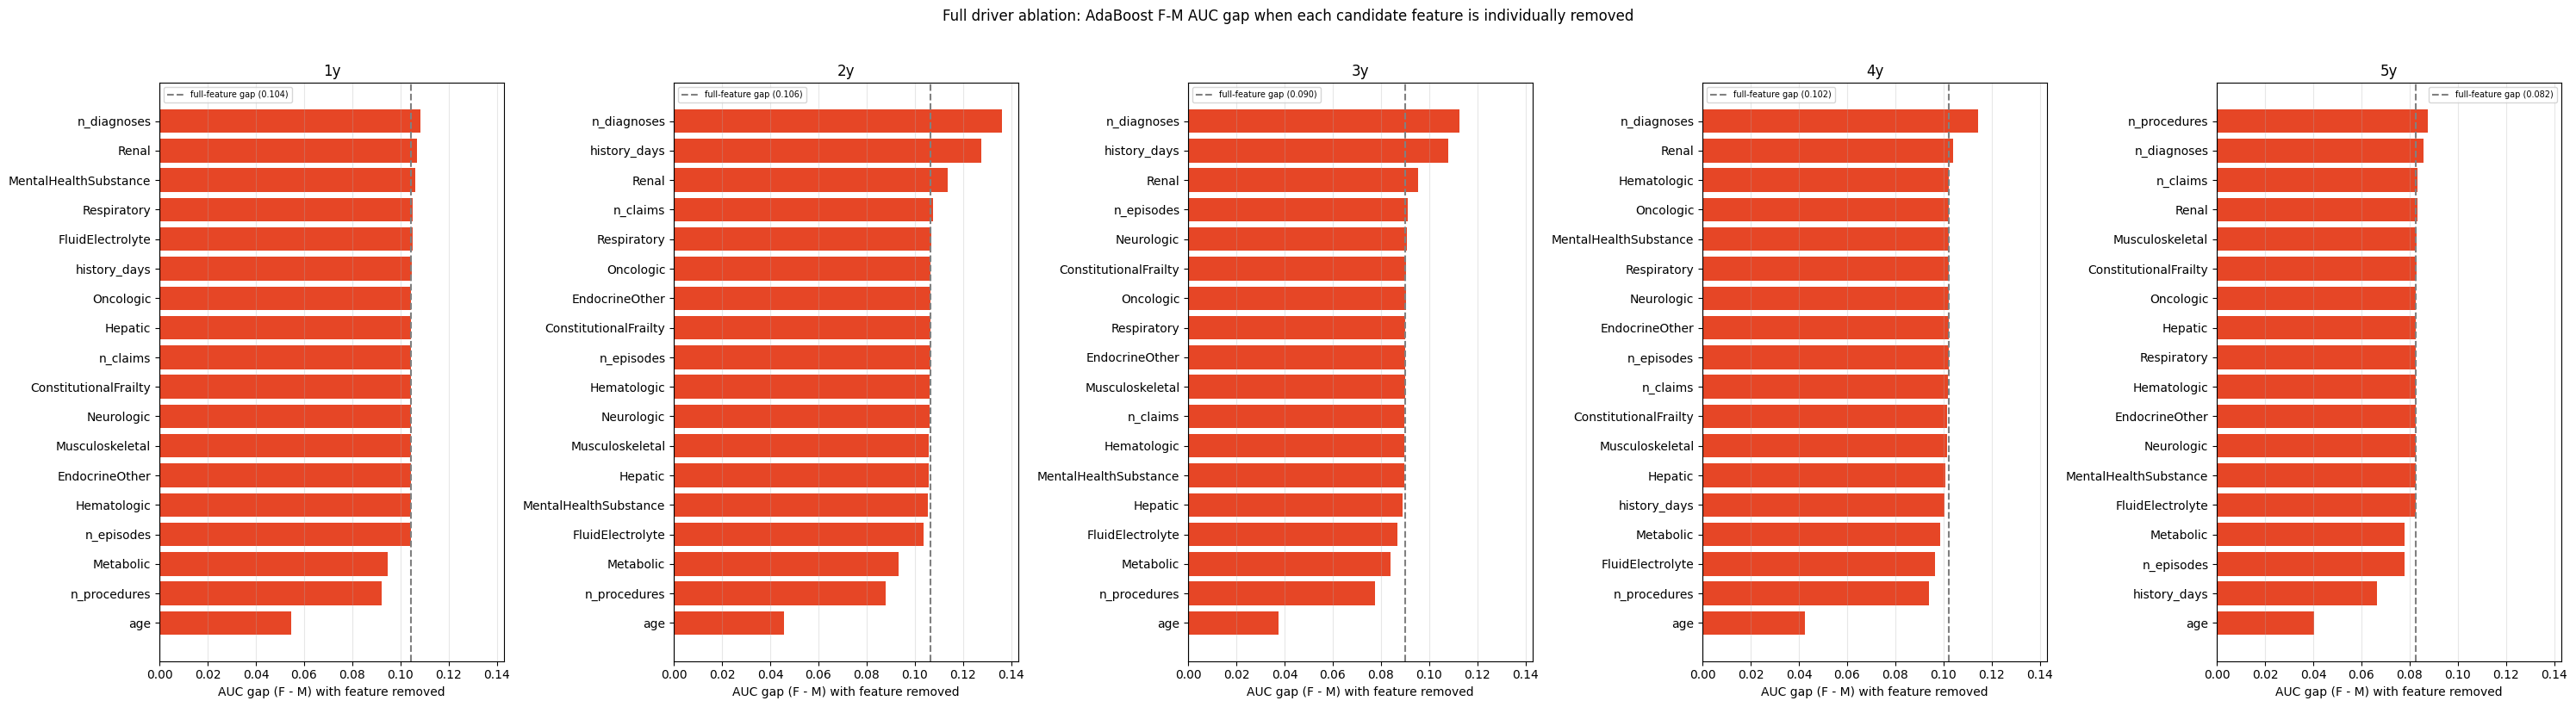

saved full_driver_ablation_chart.png


In [5]:
fig, axes = plt.subplots(1, 5, figsize=(30, 8), sharex=True)
for ax, h in zip(axes, HORIZONS):
    hsub = full_ablation_summary_df[full_ablation_summary_df.horizon == h].copy()
    baseline_gap = hsub[hsub.condition == 'Full (all features)']['gap_mean'].values[0]
    hsub = hsub[hsub.condition != 'Full (all features)'].copy()
    hsub['label'] = hsub['condition'].str.replace('No ', '').str.replace('baseline_', '').str.replace('cat_', '')
    hsub = hsub.sort_values('gap_mean')
    colors = [USYD_F if v > 0 else USYD_M for v in hsub['gap_mean']]
    ax.barh(hsub['label'], hsub['gap_mean'], color=colors)
    ax.axvline(baseline_gap, color='grey', linestyle='--', linewidth=1.5, label=f'full-feature gap ({baseline_gap:.3f})')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{h}')
    ax.set_xlabel('AUC gap (F - M) with feature removed')
    ax.legend(fontsize=7)
    ax.grid(axis='x', alpha=0.3)
plt.suptitle('Full driver ablation: AdaBoost F-M AUC gap when each candidate feature is individually removed', y=1.02)
plt.tight_layout()
plt.savefig(BASE + 'full_driver_ablation_chart.png', dpi=140, bbox_inches='tight')
plt.show()
print('saved full_driver_ablation_chart.png')